In [1]:
# Importing required libraries
import sqlite3
import numpy as np
import pandas as pd
import pandasql as ps
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime
from IPython.core.magic import register_line_magic
#import sqlalchemy
from sqlalchemy import create_engine
import pymysql as mysql
import psycopg2
from dotenv import load_dotenv

In [2]:
# Load environment variables from a .env file
load_dotenv()

True

In [3]:
'''# MYSQL CONNECTION FUNCTION
def connect_mysql():
    try:
        mysqlConn = mysql.connect(
            host=os.getenv("MYSQL_HOST", "localhost"),  
            user=os.getenv("MYSQL_USER", "root"),
            password=os.getenv("MYSQL_PASSWORD", "password"),
            database=os.getenv("MYSQL_DB", "GeeksForGeeks"),
            port=int(os.getenv("MYSQL_PORT", 3306)),
            autocommit=True,
            cursorclass=mysql.cursors.DictCursor
        )
        print("✅ MySQL Connection Successful")
        return mysqlConn
    except mysql.MySQLError as e:
        print(f"❌ MySQL Connection Error: {e}")
        return None  
    
# Close MySQLconnections function
def close_mysqlConnections(mysql_conn=None):
    if mysql_conn:
        mysql_conn.close()
        print("🔒 MySQL Connection Closed")'''

'# MYSQL CONNECTION FUNCTION\ndef connect_mysql():\n    try:\n        mysqlConn = mysql.connect(\n            host=os.getenv("MYSQL_HOST", "localhost"),  \n            user=os.getenv("MYSQL_USER", "root"),\n            password=os.getenv("MYSQL_PASSWORD", "password"),\n            database=os.getenv("MYSQL_DB", "GeeksForGeeks"),\n            port=int(os.getenv("MYSQL_PORT", 3306)),\n            autocommit=True,\n            cursorclass=mysql.cursors.DictCursor\n        )\n        print("✅ MySQL Connection Successful")\n        return mysqlConn\n    except mysql.MySQLError as e:\n        print(f"❌ MySQL Connection Error: {e}")\n        return None  \n    \n# Close MySQLconnections function\ndef close_mysqlConnections(mysql_conn=None):\n    if mysql_conn:\n        mysql_conn.close()\n        print("🔒 MySQL Connection Closed")'

In [4]:
'''# POSTGRESQL CONNECTION FUNCTION
def connect_postgresql():
    try:
        postgresqlConn = psycopg2.connect(
            host=os.getenv("POSTGRES_HOST", "localhost"),
            user=os.getenv("POSTGRES_USER", "postgres"),
            password=os.getenv("POSTGRES_PASSWORD", "password"),
            database=os.getenv("POSTGRES_DB", "postgres"),
            port=int(os.getenv("POSTGRES_PORT", 5432))
        )
        print("✅ PostgreSQL Connection Successful")
        return postgresqlConn
    except psycopg2.Error as e:
        print(f"❌ PostgreSQL Connection Error: {e}")
        return None  

# Close PostgreSQLconnections function
def close_postgresqlConnections(postgres_conn=None): 
    if postgres_conn:
        postgres_conn.close()
        print("🔒 PostgreSQL Connection Closed")'''

'# POSTGRESQL CONNECTION FUNCTION\ndef connect_postgresql():\n    try:\n        postgresqlConn = psycopg2.connect(\n            host=os.getenv("POSTGRES_HOST", "localhost"),\n            user=os.getenv("POSTGRES_USER", "postgres"),\n            password=os.getenv("POSTGRES_PASSWORD", "password"),\n            database=os.getenv("POSTGRES_DB", "postgres"),\n            port=int(os.getenv("POSTGRES_PORT", 5432))\n        )\n        print("✅ PostgreSQL Connection Successful")\n        return postgresqlConn\n    except psycopg2.Error as e:\n        print(f"❌ PostgreSQL Connection Error: {e}")\n        return None  \n\n# Close PostgreSQLconnections function\ndef close_postgresqlConnections(postgres_conn=None): \n    if postgres_conn:\n        postgres_conn.close()\n        print("🔒 PostgreSQL Connection Closed")'

In [5]:
# SQLITE CONNECTION FUNCTION
def sqliteConnections():
    try:        
        sqlitedb_path = os.getenv("SQLITE_DB", "travel.sqlite")
        with sqlite3.connect(sqlitedb_path) as sqliteConn:
            engine = create_engine(f"sqlite:///{sqlitedb_path}", echo=True) 
            print("✅ Connection Successful")
            return sqliteConn, engine  
        
    except sqlite3.Error as e:
        print(f"❌ Error Connecting to .db: {e}")
        return None, None

In [6]:
# CONNECTIONS
    #mysql_conn = connect_mysql()
    #postgres_conn = connect_postgresql()
sqlite_conn, engine = sqliteConnections()

✅ Connection Successful


In [7]:
'''def sqliteConnections():
    try:        
        sqlitedb_path = "/kaggle/input/airlines-dataset/travel.sqlite"
        with sqlite3.connect(sqlitedb_path) as sqliteConn:
            engine = create_engine(f"sqlite:////{sqlitedb_path}", echo=True) 
            print("✅ Connection Successful")
            return sqliteConn, engine  
        
    except sqlite3.Error as e:
        print(f"❌ Error Connecting to .db: {e}")'''

'def sqliteConnections():\n    try:        \n        sqlitedb_path = "/kaggle/input/airlines-dataset/travel.sqlite"\n        with sqlite3.connect(sqlitedb_path) as sqliteConn:\n            engine = create_engine(f"sqlite:////{sqlitedb_path}", echo=True) \n            print("✅ Connection Successful")\n            return sqliteConn, engine  \n        \n    except sqlite3.Error as e:\n        print(f"❌ Error Connecting to .db: {e}")'

In [8]:
# Using Pandas to read SQL tables
# Read SQL tables
query = """
SELECT name 
FROM sqlite_master 
WHERE type='table';
"""
tables = pd.read_sql(query, sqlite_conn)
tables

,name
0,aircrafts_data
1,airports_data
2,boarding_passes
3,bookings
4,flights
5,seats
6,ticket_flights
7,tickets


In [9]:
# Load SQL extension for Jupyter Notebook
%reload_ext sql

# Re-register engine
#%sql engine

In [10]:
# Connect to the database
%sql sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite

Connecting to 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

### SQL QUERIES PROGRAMMATIC ASSESSEMENT

In [12]:
# Display all the tables in the database
# !pip install jupysql
%sql SELECT name FROM sqlite_master WHERE type='table';

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

name
aircrafts_data
airports_data
boarding_passes
bookings
flights
seats
ticket_flights
tickets


In [100]:
# -- Top 10 Flight Routes by Total Revenue.
query8="""
SELECT
    fd.arrival_airport ||' - '|| fd.arrival_city AS "destination airport-city",
    ROUND(SUM(tf.amount)/1e6,0) AS "total revenue (millions)"
FROM (
    WITH da AS (
                SELECT airport_code,
                        Json_extract(airports_data.airport_name, '$.en') AS airport_name,
                        Json_extract(airports_data.city, '$.en') AS city
                FROM airports_data
                ),
        df AS (
                SELECT flight_id, 
                        flight_no,
                        departure_airport,
                        arrival_airport,
                        status,
                        aircraft_code
                FROM flights
                WHERE status IN ('Arrived', 'On Time', 'Departed')
                )
        SELECT f.flight_id,
                f.flight_no,
                f.aircraft_code,
                a1.airport_name AS departure_airport,
                a2.airport_name AS arrival_airport,
                a1.city AS departure_city,
                a2.city AS arrival_city,
                f.status
        FROM df f
        JOIN da a1
        ON f.departure_airport = a1.airport_code
        JOIN da a2
        ON f.arrival_airport = a2.airport_code
    ) fd
JOIN ticket_flights tf
ON fd.flight_id = tf.flight_id
GROUP BY "destination airport-city"
ORDER BY 2 DESC
LIMIT 10;
"""
df=pd.read_sql_query(query8, sqlite_conn)

In [101]:
# Replace " - " with a newline character "\n"
df["destination airport-city"] = df["destination airport-city"].str.replace(" - ", "\n")

C:\Users\Davie\AppData\Local\Temp\ipykernel_13336\960014740.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df["destination airport-city"],


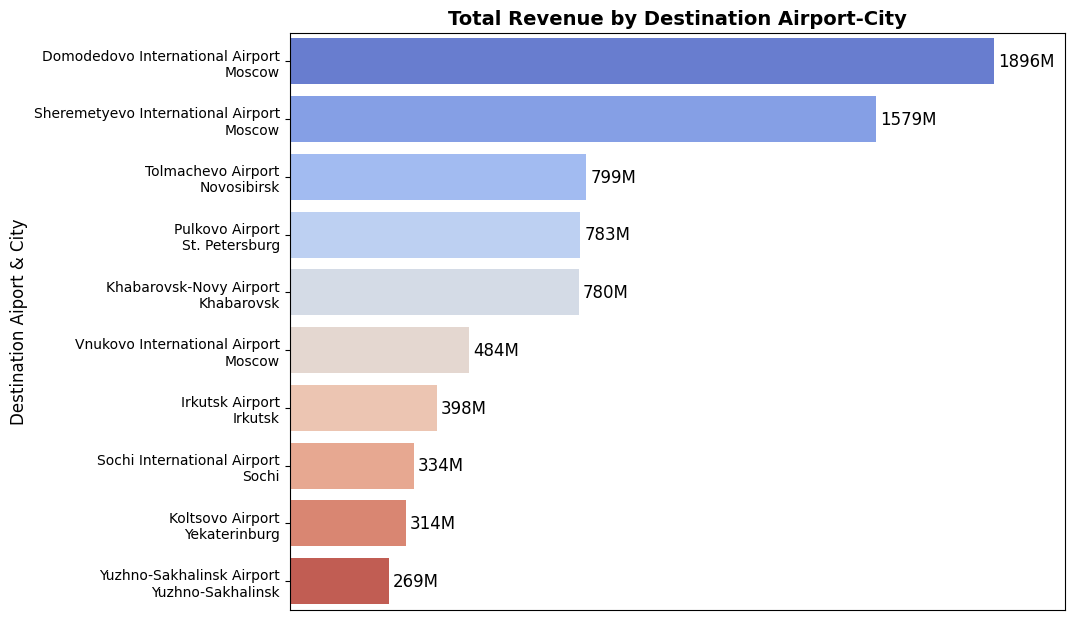

In [103]:
plt.figure(figsize=(10, 7.5))

sns.barplot(y=df["destination airport-city"],  
            x=df["total revenue (millions)"],  
            palette="coolwarm", 
            orient="h")

# Add labels next to bars
for i, value in enumerate(df["total revenue (millions)"]):
    plt.text(value + 10, i, f"{value:.0f}M", va='center', fontsize=12)

# Titles and labels
plt.title("Total Revenue by Destination Airport-City", fontsize=14, fontweight='bold')
plt.ylabel("Destination Aiport & City", fontsize=12)
plt.xlim(0, df["total revenue (millions)"].max() * 1.1)  # Add 10% space

# Remove x-axis ticks and label
plt.xticks([])
plt.xlabel('')

# Saving the plot
plt.savefig("sql-33.png", bbox_inches="tight")

# Show plot
plt.show();

In [52]:
query4="""
SELECT 
    CASE
        WHEN y.booking_date=='06' THEN 'JUNE'
        WHEN y.booking_date=='07' THEN 'JULY'
        ELSE 'AUGUST'
    END AS "Booking Month", 
     y.fare_conditions AS "Booking Class",
    ROUND(SUM(y.total_amount)/1e9,2) AS "Total Revenue (Billions)",
    CAST(SUM(ROUND(y.total_amount / y.amount, 0)) AS INTEGER) AS "Tickets Sold Per Bookings"

FROM (
    SELECT 
        t.ticket_no, 
        strftime('%m', datetime(substr(b.book_date, 1, 19))) AS booking_date,
        b.total_amount, 
        tf.fare_conditions, 
        tf.amount
    FROM tickets t
    JOIN bookings b
        ON t.book_ref = b.book_ref
    JOIN ticket_flights tf
        ON t.ticket_no = tf.ticket_no
) AS y
GROUP BY "Booking Month", "Booking Class";
"""
df=pd.read_sql_query(query4, sqlite_conn)

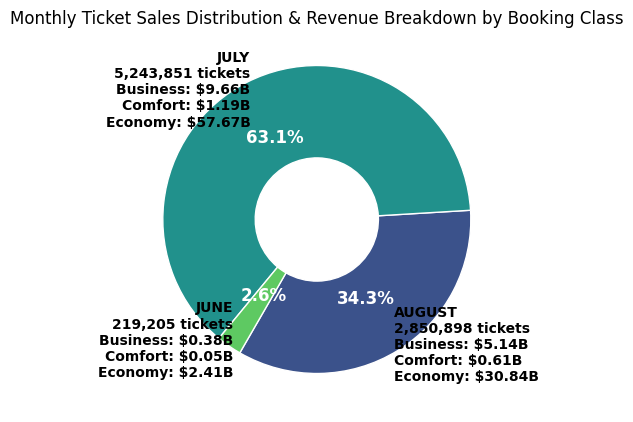

In [98]:
# Aggregate total tickets per Booking Month
monthly_tickets = df.groupby("Booking Month")["Tickets Sold Per Bookings"].sum()

# Labels with Booking Month, Tickets Sold, and Revenue Breakdown by Class
labels = []
for month in monthly_tickets.index:
    subset = df[df["Booking Month"] == month]
    revenue_details = "\n".join([f"{row['Booking Class']}: ${row['Total Revenue (Billions)']:.2f}B" for _, row in subset.iterrows()])
    
    label = f"{month}\n{monthly_tickets[month]:,} tickets\n{revenue_details}"
    labels.append(label)

# Create plot
plt.figure(figsize=(8, 5))
colors = sns.color_palette('viridis', len(monthly_tickets))

widgets, texts, autotexts = plt.pie(
    monthly_tickets, 
    labels=labels,  
    autopct='%1.1f%%', 
    startangle=240,
    colors=colors,
    wedgeprops=dict(width=0.6, edgecolor='w'),
    textprops={'fontsize': 10, 'weight': 'bold'},
    labeldistance=0.95,
    pctdistance=0.6
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

plt.title("Monthly Ticket Sales Distribution & Revenue Breakdown by Booking Class", pad=0)

plt.savefig("your.png", bbox_inches="tight")

plt.show();

In [ ]:
# Display the first 5 rows of the 'aircrafts_data' table
%sql SELECT * FROM aircrafts_data;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

aircraft_code,model,range
773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суперджет-100""}",3000
320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-200""}",5700
321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-200""}",5600
319,"{""en"": ""Airbus A319-100"", ""ru"": ""Аэробус A319-100""}",6700
733,"{""en"": ""Boeing 737-300"", ""ru"": ""Боинг 737-300""}",4200
CN1,"{""en"": ""Cessna 208 Caravan"", ""ru"": ""Сессна 208 Караван""}",1200
CR2,"{""en"": ""Bombardier CRJ-200"", ""ru"": ""Бомбардье CRJ-200""}",2700


- Extract english name for the aircrafts model

In [ ]:
# Display all the columns in the airports_data table
%sql SELECT * FROM airports_data;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

airport_code,airport_name,city,coordinates,timezone
YKS,"{""en"": ""Yakutsk Airport"", ""ru"": ""Якутск""}","{""en"": ""Yakutsk"", ""ru"": ""Якутск""}","(129.77099609375,62.0932998657226562)",Asia/Yakutsk
MJZ,"{""en"": ""Mirny Airport"", ""ru"": ""Мирный""}","{""en"": ""Mirnyj"", ""ru"": ""Мирный""}","(114.03900146484375,62.534698486328125)",Asia/Yakutsk
KHV,"{""en"": ""Khabarovsk-Novy Airport"", ""ru"": ""Хабаровск-Новый""}","{""en"": ""Khabarovsk"", ""ru"": ""Хабаровск""}","(135.18800354004,48.5279998779300001)",Asia/Vladivostok
PKC,"{""en"": ""Yelizovo Airport"", ""ru"": ""Елизово""}","{""en"": ""Petropavlovsk"", ""ru"": ""Петропавловск-Камчатский""}","(158.453994750976562,53.1679000854492188)",Asia/Kamchatka
UUS,"{""en"": ""Yuzhno-Sakhalinsk Airport"", ""ru"": ""Хомутово""}","{""en"": ""Yuzhno-Sakhalinsk"", ""ru"": ""Южно-Сахалинск""}","(142.718002319335938,46.8886985778808594)",Asia/Sakhalin
VVO,"{""en"": ""Vladivostok International Airport"", ""ru"": ""Владивосток""}","{""en"": ""Vladivostok"", ""ru"": ""Владивосток""}","(132.147994995117188,43.3989982604980469)",Asia/Vladivostok
LED,"{""en"": ""Pulkovo Airport"", ""ru"": ""Пулково""}","{""en"": ""St. Petersburg"", ""ru"": ""Санкт-Петербург""}","(30.2625007629394531,59.8003005981445312)",Europe/Moscow
KGD,"{""en"": ""Khrabrovo Airport"", ""ru"": ""Храброво""}","{""en"": ""Kaliningrad"", ""ru"": ""Калининград""}","(20.5925998687744141,54.8899993896484375)",Europe/Kaliningrad
KEJ,"{""en"": ""Kemerovo Airport"", ""ru"": ""Кемерово""}","{""en"": ""Kemorovo"", ""ru"": ""Кемерово""}","(86.1072006225585938,55.2700996398925781)",Asia/Novokuznetsk
CEK,"{""en"": ""Chelyabinsk Balandino Airport"", ""ru"": ""Челябинск""}","{""en"": ""Chelyabinsk"", ""ru"": ""Челябинск""}","(61.503300000000003,55.3058010000000024)",Asia/Yekaterinburg


- Extract english name for the airport_name and city

In [ ]:
# Display all the columns in the boarding_passes table
%sql SELECT * FROM boarding_passes;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

ticket_no,flight_id,boarding_no,seat_no
0005435212351,30625,1,2D
0005435212386,30625,2,3G
0005435212381,30625,3,4H
0005432211370,30625,4,5D
0005435212357,30625,5,11A
0005435212360,30625,6,11E
0005435212393,30625,7,11H
0005435212374,30625,8,12E
0005435212365,30625,9,13D
0005435212378,30625,10,14H


In [ ]:
# Display all the columns in the bookings table
%sql SELECT * FROM bookings;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

book_ref,book_date,total_amount
00000F,2017-07-05 03:12:00+03,265700
000012,2017-07-14 09:02:00+03,37900
000068,2017-08-15 14:27:00+03,18100
000181,2017-08-10 13:28:00+03,131800
0002D8,2017-08-07 21:40:00+03,23600
0002DB,2017-07-29 06:30:00+03,101500
0002E0,2017-07-11 16:09:00+03,89600
0002F3,2017-07-10 05:31:00+03,69600
00034E,2017-08-04 16:52:00+03,73300
000352,2017-07-06 02:02:00+03,109500


In [ ]:
# Display all the columns in the flights table
%sql SELECT * FROM flights;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
1185,PG0134,2017-09-10 09:50:00+03,2017-09-10 14:55:00+03,DME,BTK,Scheduled,319,\N,\N
3979,PG0052,2017-08-25 14:50:00+03,2017-08-25 17:35:00+03,VKO,HMA,Scheduled,CR2,\N,\N
4739,PG0561,2017-09-05 12:30:00+03,2017-09-05 14:15:00+03,VKO,AER,Scheduled,763,\N,\N
5502,PG0529,2017-09-12 09:50:00+03,2017-09-12 11:20:00+03,SVO,UFA,Scheduled,763,\N,\N
6938,PG0461,2017-09-04 12:25:00+03,2017-09-04 13:20:00+03,SVO,ULV,Scheduled,SU9,\N,\N
7784,PG0667,2017-09-10 15:00:00+03,2017-09-10 17:30:00+03,SVO,KRO,Scheduled,CR2,\N,\N
9478,PG0360,2017-08-28 09:00:00+03,2017-08-28 11:35:00+03,LED,REN,Scheduled,CR2,\N,\N
11085,PG0569,2017-08-24 15:05:00+03,2017-08-24 16:10:00+03,SVX,SCW,Scheduled,733,\N,\N
11847,PG0498,2017-09-12 10:15:00+03,2017-09-12 14:55:00+03,KZN,IKT,Scheduled,319,\N,\N
12012,PG0621,2017-08-26 16:05:00+03,2017-08-26 17:00:00+03,KZN,MQF,Scheduled,CR2,\N,\N


In [ ]:
# Display all the columns in the seats table
%sql SELECT * FROM seats;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

aircraft_code,seat_no,fare_conditions
319,2A,Business
319,2C,Business
319,2D,Business
319,2F,Business
319,3A,Business
319,3C,Business
319,3D,Business
319,3F,Business
319,4A,Business
319,4C,Business


In [ ]:
# Display all the columns in the ticket_flights table
%sql SELECT * FROM ticket_flights;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

ticket_no,flight_id,fare_conditions,amount
0005432159776,30625,Business,42100
0005435212351,30625,Business,42100
0005435212386,30625,Business,42100
0005435212381,30625,Business,42100
0005432211370,30625,Business,42100
0005435212357,30625,Comfort,23900
0005435212360,30625,Comfort,23900
0005435212393,30625,Comfort,23900
0005435212374,30625,Comfort,23900
0005435212365,30625,Comfort,23900


In [ ]:
# Display all the columns in the tickets table
%sql SELECT * FROM tickets;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

ticket_no,book_ref,passenger_id
0005432000987,06B046,8149 604011
0005432000988,06B046,8499 420203
0005432000989,E170C3,1011 752484
0005432000990,E170C3,4849 400049
0005432000991,F313DD,6615 976589
0005432000992,F313DD,2021 652719
0005432000993,F313DD,0817 363231
0005432000994,CCC5CB,2883 989356
0005432000995,CCC5CB,3097 995546
0005432000996,1FB1E4,6866 920231


In [ ]:
%%sql

WITH flight_data AS (
       SELECT 
                f.flight_id,
                f.flight_no,
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.scheduled_arrival, 1, 19)) AS scheduled_arrival,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                f.departure_airport,
                f.arrival_airport,
                f.status,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap1.city, '$.en') AS departure_city,
                ap1.coordinates AS departure_city_coordinates,
                ap1.timezone AS departure_timezone,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name,
                json_extract(ap2.city, '$.en') AS arrival_city,
                ap2.coordinates AS arrival_city_coordinates,
                ap2.timezone AS arrival_timezone
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        )

SELECT *
FROM flight_data
WHERE actual_departure !='\\N' OR actual_arrival !='\\N';

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

flight_id,flight_no,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,departure_airport,arrival_airport,status,departure_airport_name,departure_city,departure_city_coordinates,departure_timezone,arrival_airport_name,arrival_city,arrival_city_coordinates,arrival_timezone
1,PG0405,2017-07-16 09:35:00,2017-07-16 09:44:00,2017-07-16 10:30:00,2017-07-16 10:39:00,DME,LED,Arrived,Domodedovo International Airport,Moscow,"(37.9062995910644531,55.4087982177734375)",Europe/Moscow,Pulkovo Airport,St. Petersburg,"(30.2625007629394531,59.8003005981445312)",Europe/Moscow
2,PG0404,2017-08-05 19:05:00,2017-08-05 19:06:00,2017-08-05 20:00:00,2017-08-05 20:01:00,DME,LED,Arrived,Domodedovo International Airport,Moscow,"(37.9062995910644531,55.4087982177734375)",Europe/Moscow,Pulkovo Airport,St. Petersburg,"(30.2625007629394531,59.8003005981445312)",Europe/Moscow
3,PG0405,2017-08-05 09:35:00,2017-08-05 09:39:00,2017-08-05 10:30:00,2017-08-05 10:34:00,DME,LED,Arrived,Domodedovo International Airport,Moscow,"(37.9062995910644531,55.4087982177734375)",Europe/Moscow,Pulkovo Airport,St. Petersburg,"(30.2625007629394531,59.8003005981445312)",Europe/Moscow
14,PG0402,2017-08-06 12:25:00,2017-08-06 12:28:00,2017-08-06 13:20:00,2017-08-06 13:23:00,DME,LED,Arrived,Domodedovo International Airport,Moscow,"(37.9062995910644531,55.4087982177734375)",Europe/Moscow,Pulkovo Airport,St. Petersburg,"(30.2625007629394531,59.8003005981445312)",Europe/Moscow
15,PG0402,2017-07-28 12:25:00,2017-07-28 12:31:00,2017-07-28 13:20:00,2017-07-28 13:26:00,DME,LED,Arrived,Domodedovo International Airport,Moscow,"(37.9062995910644531,55.4087982177734375)",Europe/Moscow,Pulkovo Airport,St. Petersburg,"(30.2625007629394531,59.8003005981445312)",Europe/Moscow
16,PG0403,2017-08-06 11:25:00,2017-08-06 11:27:00,2017-08-06 12:20:00,2017-08-06 12:22:00,DME,LED,Arrived,Domodedovo International Airport,Moscow,"(37.9062995910644531,55.4087982177734375)",Europe/Moscow,Pulkovo Airport,St. Petersburg,"(30.2625007629394531,59.8003005981445312)",Europe/Moscow
17,PG0404,2017-08-06 19:05:00,2017-08-06 19:05:00,2017-08-06 20:00:00,2017-08-06 20:00:00,DME,LED,Arrived,Domodedovo International Airport,Moscow,"(37.9062995910644531,55.4087982177734375)",Europe/Moscow,Pulkovo Airport,St. Petersburg,"(30.2625007629394531,59.8003005981445312)",Europe/Moscow
18,PG0405,2017-08-06 09:35:00,2017-08-06 09:39:00,2017-08-06 10:30:00,2017-08-06 10:35:00,DME,LED,Arrived,Domodedovo International Airport,Moscow,"(37.9062995910644531,55.4087982177734375)",Europe/Moscow,Pulkovo Airport,St. Petersburg,"(30.2625007629394531,59.8003005981445312)",Europe/Moscow
19,PG0403,2017-07-28 11:25:00,2017-07-28 11:27:00,2017-07-28 12:20:00,2017-07-28 12:22:00,DME,LED,Arrived,Domodedovo International Airport,Moscow,"(37.9062995910644531,55.4087982177734375)",Europe/Moscow,Pulkovo Airport,St. Petersburg,"(30.2625007629394531,59.8003005981445312)",Europe/Moscow
20,PG0403,2017-07-26 11:25:00,2017-07-26 11:28:00,2017-07-26 12:20:00,2017-07-26 12:23:00,DME,LED,Arrived,Domodedovo International Airport,Moscow,"(37.9062995910644531,55.4087982177734375)",Europe/Moscow,Pulkovo Airport,St. Petersburg,"(30.2625007629394531,59.8003005981445312)",Europe/Moscow


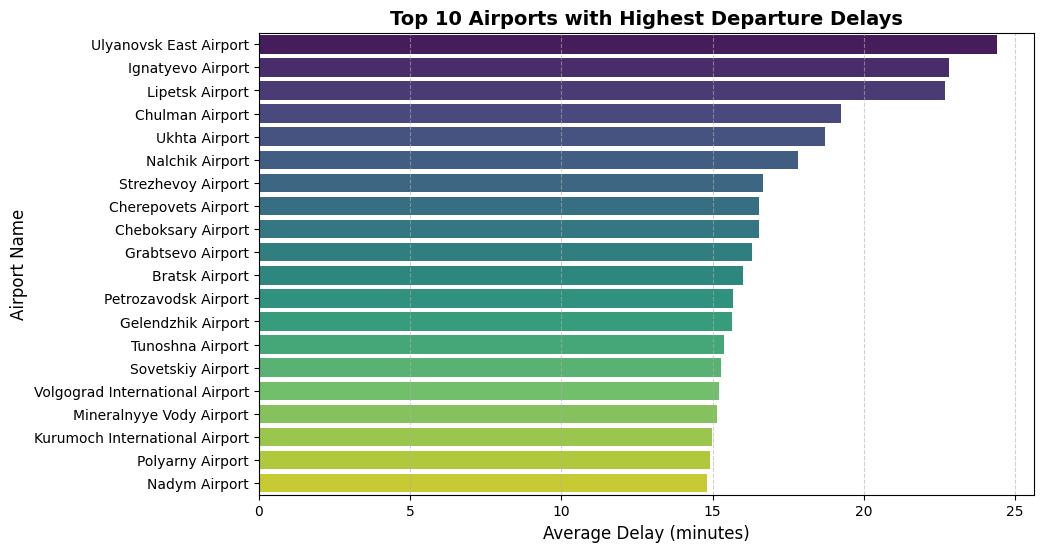

In [ ]:
# Top 10 Airports with the Most Delays
querry="""
WITH flight_data AS (
       SELECT 
                f.flight_id,
                f.flight_no,
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.scheduled_arrival, 1, 19)) AS scheduled_arrival,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                f.departure_airport,
                f.arrival_airport,
                f.status,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap1.city, '$.en') AS departure_city,
                ap1.coordinates AS departure_city_coordinates,
                ap1.timezone AS departure_timezone,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name,
                json_extract(ap2.city, '$.en') AS arrival_city,
                ap2.coordinates AS arrival_city_coordinates,
                ap2.timezone AS arrival_timezone
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        )

SELECT departure_airport_name, 
        ROUND(AVG(strftime('%s', datetime(actual_departure)) - strftime('%s', datetime(scheduled_departure)))/60,2) AS 'avg_delay (minutes)'
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY departure_airport_name
ORDER BY 2 DESC
LIMIT 20;
"""
df=pd.read_sql_query(querry, sqlite_conn)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=df['avg_delay (minutes)'], y=df['departure_airport_name'], palette='viridis', hue=df['departure_airport_name'])
plt.grid(axis='x', linestyle='--', alpha=0.6)
# Add labels and title
plt.xlabel('Average Delay (minutes)', fontsize=12)
plt.ylabel('Airport Name', fontsize=12)
plt.title('Top 10 Airports with Highest Departure Delays', fontsize=14, fontweight='bold')
# Show the plot
plt.show();

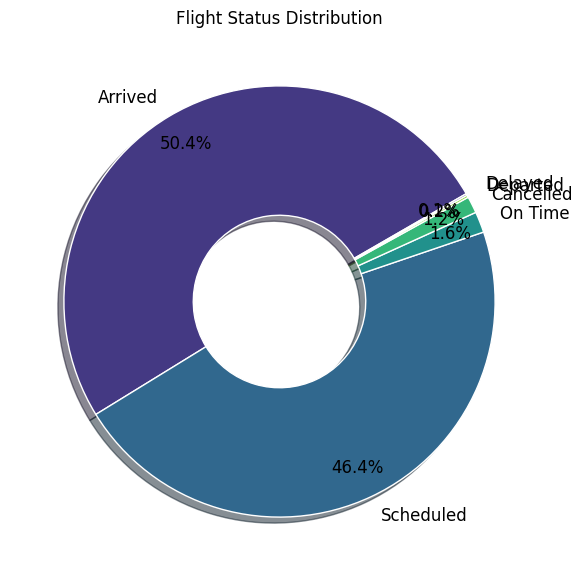

In [ ]:
# Flight Status Distribution
querry="""
WITH flight_data AS (
       SELECT 
                f.flight_id,
                f.flight_no,
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.scheduled_arrival, 1, 19)) AS scheduled_arrival,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                f.departure_airport,
                f.arrival_airport,
                f.status,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap1.city, '$.en') AS departure_city,
                ap1.coordinates AS departure_city_coordinates,
                ap1.timezone AS departure_timezone,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name,
                json_extract(ap2.city, '$.en') AS arrival_city,
                ap2.coordinates AS arrival_city_coordinates,
                ap2.timezone AS arrival_timezone
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        )

SELECT status, 
        COUNT(*) AS Counts
FROM flight_data
GROUP BY status
ORDER BY 2 DESC;
"""
df=pd.read_sql_query(querry, sqlite_conn)
plt.figure(figsize=(7, 7))
plt.pie(df['Counts'], labels=df['status'], 
        autopct='%1.1f%%', startangle=30, 
        colors=sns.color_palette('viridis', 5),
        wedgeprops=dict(width=0.6, edgecolor='w'),
        textprops={'fontsize': 12},
        shadow=True,
        pctdistance=0.85)

plt.title('Flight Status Distribution')
plt.show();

In [ ]:
# Top 10 Most Delayed Flights
querry="""
WITH flight_data AS (
       SELECT 
                f.flight_id,
                f.flight_no,
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.scheduled_arrival, 1, 19)) AS scheduled_arrival,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                f.departure_airport,
                f.arrival_airport,
                f.status,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap1.city, '$.en') AS departure_city,
                ap1.coordinates AS departure_city_coordinates,
                ap1.timezone AS departure_timezone,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name,
                json_extract(ap2.city, '$.en') AS arrival_city,
                ap2.coordinates AS arrival_city_coordinates,
                ap2.timezone AS arrival_timezone
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        )

SELECT flight_no, 
        ROUND(CAST(strftime('%s', datetime(actual_departure)) - strftime('%s', datetime(scheduled_departure)) AS FLOAT)/3600,2) AS 'delay hours'
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY flight_no 
ORDER BY 2 DESC
LIMIT 10;
"""
dff=pd.read_sql_query(querry, sqlite_conn)
dff

,flight_no,delay hours
0,PG0086,3.70
1,PG0526,3.65
2,PG0583,3.55
3,PG0044,3.55
4,PG0696,3.47
5,PG0414,3.38
6,PG0103,3.37
7,PG0638,3.35
8,PG0590,3.32
9,PG0677,3.30


In [ ]:
'''# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=df['avg_delay (minutes)'], y=df['departure_airport_name'], palette='viridis', hue=df['departure_airport_name'])
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Add labels and title
plt.xlabel('Average Delay (minutes)')
plt.ylabel('Airport Name')
plt.title('Top 10 Airports with Highest Departure Delays')

# Show the plot
plt.show();'''

"# Plot\nplt.figure(figsize=(10, 6))\nsns.barplot(x=df['avg_delay (minutes)'], y=df['departure_airport_name'], palette='viridis', hue=df['departure_airport_name'])\nplt.grid(axis='x', linestyle='--', alpha=0.6)\n\n# Add labels and title\nplt.xlabel('Average Delay (minutes)')\nplt.ylabel('Airport Name')\nplt.title('Top 10 Airports with Highest Departure Delays')\n\n# Show the plot\nplt.show();"

# add arrival_city=aircraft model

In [ ]:
%%sql
--# Top 10 Most Delayed Flights
WITH flight_data AS (
       SELECT 
                f.flight_no,
                json_extract(ap2.city, '$.en') AS arrival_city,
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival
             
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        )

SELECT flight_no, arrival_city,
        ROUND(CAST(strftime('%s', datetime(actual_departure)) - strftime('%s', datetime(scheduled_departure)) AS FLOAT)/3600,2) AS 'delay hours'
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY flight_no 
ORDER BY 3 DESC
LIMIT 10;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

flight_no,arrival_city,delay hours
PG0086,Moscow,3.7
PG0526,Kazan,3.65
PG0583,Abakan,3.55
PG0044,Moscow,3.55
PG0696,Volgograd,3.47
PG0414,Murmansk,3.38
PG0103,Kogalym,3.37
PG0638,Moscow,3.35
PG0590,Yekaterinburg,3.32
PG0677,Makhachkala,3.3


In [ ]:
# Most Popular Flight Hours
querry="""
WITH flight_data AS (
       SELECT 
                f.flight_id,
                f.flight_no,
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.scheduled_arrival, 1, 19)) AS scheduled_arrival,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                f.departure_airport,
                f.arrival_airport,
                f.status,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap1.city, '$.en') AS departure_city,
                ap1.coordinates AS departure_city_coordinates,
                ap1.timezone AS departure_timezone,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name,
                json_extract(ap2.city, '$.en') AS arrival_city,
                ap2.coordinates AS arrival_city_coordinates,
                ap2.timezone AS arrival_timezone
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        )

SELECT strftime('%HH', datetime(scheduled_departure)) AS departure_hour, 
       COUNT(*) AS flight_count
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY departure_hour
ORDER BY 1 ASC
LIMIT 10;
"""
df_hour=pd.read_sql_query(querry, sqlite_conn)
df_hour


,departure_hour,flight_count
0,01H,5
1,02H,35
2,03H,132
3,04H,54
4,05H,190
5,06H,272
6,07H,687
7,08H,646
8,09H,1640
9,10H,1545


In [ ]:
%%sql
--# Most Popular Flight Hours
WITH flight_data AS (
       SELECT 
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name

        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
)

SELECT strftime('%HH', datetime(scheduled_departure)) AS departure_hour,
        departure_airport_name || ' - ' || arrival_airport_name AS route,
       COUNT(*) AS flight_count
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY departure_hour, route
ORDER BY 1 ASC
LIMIT 10;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

departure_hour,route,flight_count
01H,Ugolny Airport - Vnukovo International Airport,5
02H,Ugolny Airport - Khabarovsk-Novy Airport,4
02H,Vladivostok International Airport - Khabarovsk-Novy Airport,31
03H,Chulman Airport - Mirny Airport,31
03H,Khabarovsk-Novy Airport - Ugolny Airport,4
03H,Ugolny Airport - Sheremetyevo International Airport,4
03H,Vladivostok International Airport - Irkutsk Airport,31
03H,Yakutsk Airport - Pulkovo Airport,31
03H,Yuzhno-Sakhalinsk Airport - Khabarovsk-Novy Airport,31
04H,Chulman Airport - Astrakhan Airport,5


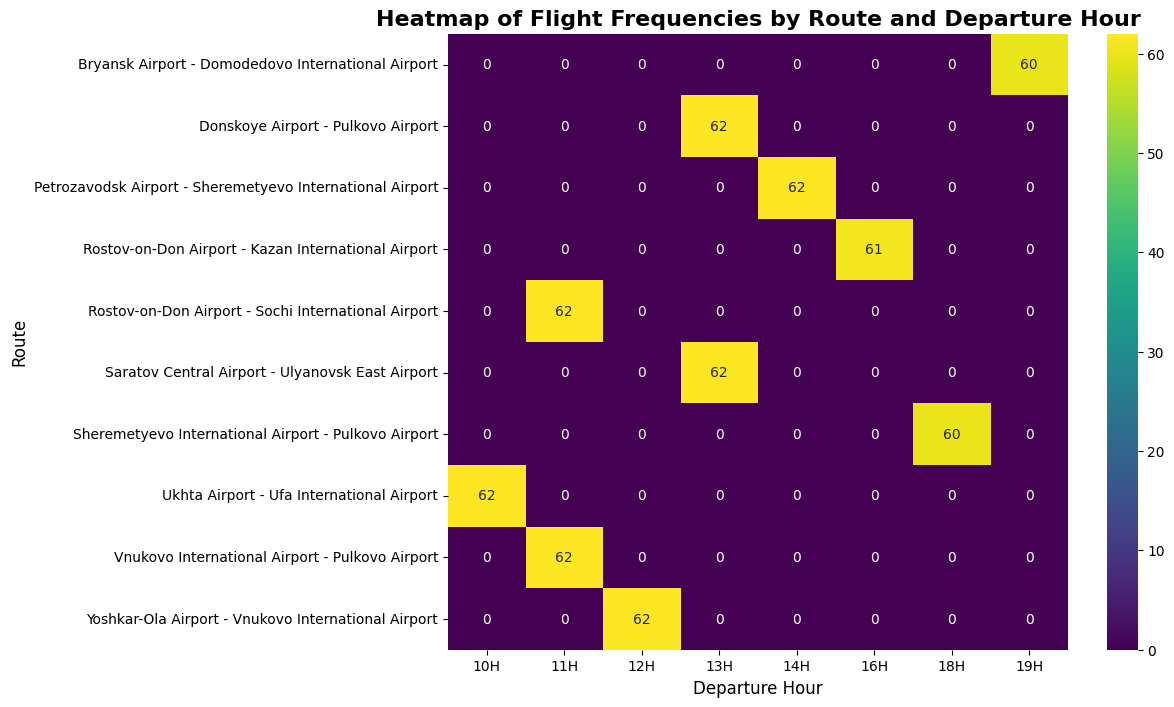

In [ ]:
# Most Popular Flight Hours
querry="""
WITH flight_data AS (
       SELECT 
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name

        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
)

SELECT strftime('%HH', datetime(scheduled_departure)) AS departure_hour,
        departure_airport_name || ' - ' || arrival_airport_name AS route,
       COUNT(*) AS flight_count
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY departure_hour, route
ORDER BY 3 DESC
LIMIT 10;
"""
df_hour=pd.read_sql_query(querry, sqlite_conn)
# Plot
df_pivot = df_hour.pivot(index='route', columns='departure_hour', values='flight_count').fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(df_pivot, cmap='viridis', annot=True, fmt='.0f')

plt.xlabel('Departure Hour', fontsize=12)
plt.ylabel('Route', fontsize=12)
plt.title('Heatmap of Flight Frequencies by Route and Departure Hour', fontsize=16, fontweight='bold')

plt.show()

In [ ]:
# Peak Travel Days
querry="""
WITH flight_data AS (
       SELECT 
                f.flight_id,
                f.flight_no,
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.scheduled_arrival, 1, 19)) AS scheduled_arrival,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                f.departure_airport,
                f.arrival_airport,
                f.status,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap1.city, '$.en') AS departure_city,
                ap1.coordinates AS departure_city_coordinates,
                ap1.timezone AS departure_timezone,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name,
                json_extract(ap2.city, '$.en') AS arrival_city,
                ap2.coordinates AS arrival_city_coordinates,
                ap2.timezone AS arrival_timezone
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        )

SELECT  status,
        CASE strftime('%w', scheduled_departure)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
        END AS flight_weekday,

        

       COUNT(*) AS total_flights

FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N" AND status = "Arrived"
GROUP BY  status, flight_weekday
ORDER BY 1 DESC
LIMIT 10;
"""
df_days=pd.read_sql_query(querry, sqlite_conn)
df_days

,status,flight_weekday,total_flights
0,Departed,Tuesday,58
1,Cancelled,Friday,1
2,Cancelled,Saturday,1
3,Cancelled,Thursday,1
4,Cancelled,Tuesday,1
5,Cancelled,Wednesday,4
6,Arrived,Friday,1971
7,Arrived,Monday,2680
8,Arrived,Saturday,2271
9,Arrived,Sunday,2790


In [ ]:
%%sql
WITH flight_data AS (
       SELECT 
                f.flight_id,
                f.flight_no,
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.scheduled_arrival, 1, 19)) AS scheduled_arrival,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                f.departure_airport,
                f.arrival_airport,
                f.status,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap1.city, '$.en') AS departure_city,
                ap1.coordinates AS departure_city_coordinates,
                ap1.timezone AS departure_timezone,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name,
                json_extract(ap2.city, '$.en') AS arrival_city,
                ap2.coordinates AS arrival_city_coordinates,
                ap2.timezone AS arrival_timezone
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        )

SELECT  status,
        CASE strftime('%w', scheduled_departure)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
        END AS flight_weekday,

        

       COUNT(*) AS total_flights

FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY  status, flight_weekday
ORDER BY 3 DESC
LIMIT 10;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

status,flight_weekday,total_flights
Arrived,Sunday,2790
Arrived,Monday,2680
Arrived,Tuesday,2608
Arrived,Saturday,2271
Arrived,Thursday,2199
Arrived,Wednesday,2188
Arrived,Friday,1971
Departed,Tuesday,58
Cancelled,Wednesday,4
Cancelled,Friday,1


In [ ]:
%%sql 
-- longest flight-Identify the flights that experienced the longest delays.
WITH flight_data AS (
       SELECT 
                f.flight_id,
                f.flight_no,
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.scheduled_arrival, 1, 19)) AS scheduled_arrival,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                f.departure_airport,
                f.arrival_airport,
                f.status,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap1.city, '$.en') AS departure_city,
                ap1.coordinates AS departure_city_coordinates,
                ap1.timezone AS departure_timezone,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name,
                json_extract(ap2.city, '$.en') AS arrival_city,
                ap2.coordinates AS arrival_city_coordinates,
                ap2.timezone AS arrival_timezone
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        )
SELECT 
    flight_no,
    departure_airport,
    arrival_airport,
    (julianday(actual_departure) - julianday(scheduled_departure)) * 1440 AS departure_delay_minutes,
    (julianday(actual_arrival) - julianday(scheduled_arrival)) * 1440 AS arrival_delay_minutes
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY flight_no, departure_airport, arrival_airport
ORDER BY 5 DESC
LIMIT 10;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

flight_no,departure_airport,arrival_airport,departure_delay_minutes,arrival_delay_minutes
PG0086,LPK,DME,221.99999950826168,222.00000017881393
PG0526,MCX,KZN,218.99999968707561,218.99999968707561
PG0583,OVB,ABA,213.00000004470348,213.99999998509884
PG0044,IJK,SVO,213.00000004470348,213.00000004470348
PG0696,TOF,VOG,208.0000003427267,207.99999967217445
PG0414,VKO,MMK,202.99999997019768,205.99999979138374
PG0638,KVX,SVO,201.00000008940697,201.00000008940697
PG0103,SVX,KGP,202.00000002980232,200.0000001490116
PG0590,PEE,SVX,199.00000020861626,199.00000020861626
PG0503,SVO,OMS,198.0000002682209,198.0000002682209


In [ ]:
%%sql 
-- Most Popular Flight Routes/Cities-Connected cities/Busiest Routes (Top Origin-Destination Pairs)
--Find the most frequently traveled routes
WITH flight_data AS (
       SELECT 
                f.flight_id,
                f.flight_no,
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.scheduled_arrival, 1, 19)) AS scheduled_arrival,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                f.departure_airport,
                f.arrival_airport,
                f.status,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap1.city, '$.en') AS departure_city,
                ap1.coordinates AS departure_city_coordinates,
                ap1.timezone AS departure_timezone,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name,
                json_extract(ap2.city, '$.en') AS arrival_city,
                ap2.coordinates AS arrival_city_coordinates,
                ap2.timezone AS arrival_timezone
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        ),
    route AS (
        SELECT 
            CASE 
                WHEN departure_city < arrival_city THEN departure_city || ' to ' || arrival_city 
                ELSE arrival_city || ' to ' || departure_city 
            END AS route
        FROM flight_data
        WHERE actual_departure !="\\N" OR actual_arrival !="\\N")
SELECT route, COUNT(*) AS flight_count
FROM route
GROUP BY route
ORDER BY 2 DESC;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

route,flight_count
Moscow to St. Petersburg,739
Bryansk to Moscow,552
Moscow to Ulyanovsk,306
Moscow to Yoshkar-Ola,248
Moscow to Petrozavodsk,247
Moscow to Sovetskiy,186
Moscow to Penza,185
Moscow to Rostov,183
Ufa to Ukhta,124
Surgut to Vorkuta,124


In [ ]:
%%sql

WITH flight_data AS (
       SELECT 
                f.flight_id,
                f.flight_no,
                datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
                datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
                datetime(substr(f.scheduled_arrival, 1, 19)) AS scheduled_arrival,
                datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
                f.departure_airport,
                f.arrival_airport,
                f.status,
                json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
                json_extract(ap1.city, '$.en') AS departure_city,
                ap1.coordinates AS departure_city_coordinates,
                ap1.timezone AS departure_timezone,
                json_extract(ap2.airport_name, '$.en') AS arrival_airport_name,
                json_extract(ap2.city, '$.en') AS arrival_city,
                ap2.coordinates AS arrival_city_coordinates,
                ap2.timezone AS arrival_timezone
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        )

SELECT strftime('%HH', datetime(scheduled_departure)) AS departure_hour, 
       COUNT(*) AS flight_count
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY departure_hour
ORDER BY 2 DESC
LIMIT 10;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

departure_hour,flight_count
11H,2037
14H,1681
13H,1641
09H,1640
10H,1545
12H,1544
15H,1380
16H,1068
18H,768
07H,687


In [ ]:
#'f.flight_id, COUNT(bp.seat_no) * 1.0 / COUNT(s.seat_no) AS occupancy_rate'

In [ ]:
%%sql
SELECT 
        k.ticket_no,
        k.flight_id,
        s.aircraft_code,
        json_extract(model, '$.en') AS aircraft_model_name,
	s.fare_conditions,
        k.amount,
        b.boarding_no,	
        s.seat_no
FROM ticket_flights k
INNER JOIN boarding_passes b 
        ON k.ticket_no = b.ticket_no
        AND k.flight_id = b.flight_id
INNER JOIN seats s
        ON k.fare_conditions = s.fare_conditions
        AND b.seat_no=s.seat_no
INNER JOIN aircrafts_data ac
        ON s.aircraft_code=ac.aircraft_code;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

ticket_no,flight_id,aircraft_code,aircraft_model_name,fare_conditions,amount,boarding_no,seat_no
0005432159776,30625,319,Airbus A319-100,Business,42100,24,2A
0005432159776,30625,320,Airbus A320-200,Business,42100,24,2A
0005432159776,30625,321,Airbus A321-200,Business,42100,24,2A
0005432159776,30625,733,Boeing 737-300,Business,42100,24,2A
0005432159776,30625,763,Boeing 767-300,Business,42100,24,2A
0005432159776,30625,773,Boeing 777-300,Business,42100,24,2A
0005432159776,30625,SU9,Sukhoi Superjet-100,Business,42100,24,2A
0005435212351,30625,319,Airbus A319-100,Business,42100,1,2D
0005435212351,30625,320,Airbus A320-200,Business,42100,1,2D
0005435212351,30625,321,Airbus A321-200,Business,42100,1,2D


In [ ]:
%%sql
--#Airport & Aircraft Utilization-Most Frequently Used Aircrafts-
--# Find out which aircraft models operate the most flights.
SELECT ac.aircraft_model, 
        COUNT(DISTINCT ac.flight_id) AS total_flights
FROM (
    WITH flight_data2 AS (
        SELECT 
            f.flight_id,	
            f.flight_no,
            departure_airport,
            arrival_airport,
            f.status,
            --f.actual_departure,
            --f.actual_arrival,
            b.ticket_no,	
            b.aircraft_model_name,
            b.fare_conditions,
            b.amount,	
            b.boarding_no,
            b.seat_no
        FROM flights f
        LEFT JOIN (
            SELECT 
                    k.ticket_no,
                    k.flight_id,
                    s.aircraft_code,
                    json_extract(model, '$.en') AS aircraft_model_name,
	                s.fare_conditions,
                    k.amount,
                    b.boarding_no,	
                    s.seat_no
            FROM ticket_flights k
            INNER JOIN boarding_passes b 
                ON k.ticket_no = b.ticket_no
                AND k.flight_id = b.flight_id
            INNER JOIN seats s
                ON k.fare_conditions = s.fare_conditions
                AND b.seat_no=s.seat_no
            INNER JOIN aircrafts_data ac
                ON s.aircraft_code=ac.aircraft_code) AS b

        ON f.flight_id = b.flight_id 
        AND f.aircraft_code=b.aircraft_code
        WHERE f.actual_departure !="\\N" OR f.actual_arrival !="\\N"
),

airport_name AS (
    SELECT airport_code,
            json_extract(airport_name, '$.en') AS airport_name
    FROM airports_data
)
SELECT 
        ff.flight_id,
        ff.flight_no,
        a1.airport_name AS departure_airport,
        a2.airport_name AS arrival_airport,
        ff.status,
        ff.ticket_no,	
        ff.aircraft_model_name AS aircraft_model,
        ff.fare_conditions,
        ff.amount,	
        ff.boarding_no,
        ff.seat_no
FROM flight_data2 ff
LEFT JOIN airport_name a1
ON ff.departure_airport=a1.airport_code
LEFT JOIN airport_name a2
ON ff.arrival_airport=a2.airport_code) AS ac

WHERE aircraft_model IS NOT NULL
GROUP BY ac.aircraft_model
ORDER BY 2 DESC
LIMIT 10;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

aircraft_model,total_flights
Bombardier CRJ-200,3906
Sukhoi Superjet-100,3550
Cessna 208 Caravan,1354
Airbus A321-200,650
Boeing 767-300,606
Boeing 737-300,595
Airbus A319-100,547
Boeing 777-300,310


In [ ]:
%%sql
--#Revenue by Destination Airport
--#Find out which airports bring in the most revenue.

SELECT 
    flight_id,
    flight_no,
    departure_airport,
    arrival_airport, 
    status,
    aircraft_code
FROM flights
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
ORDER BY flight_id ASC;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

flight_id,flight_no,departure_airport,arrival_airport,status,aircraft_code
1,PG0405,DME,LED,Arrived,321
2,PG0404,DME,LED,Arrived,321
3,PG0405,DME,LED,Arrived,321
4,PG0402,DME,LED,Scheduled,321
5,PG0405,DME,LED,On Time,321
6,PG0404,DME,LED,Scheduled,321
7,PG0403,DME,LED,Delayed,321
8,PG0402,DME,LED,On Time,321
9,PG0405,DME,LED,Scheduled,321
10,PG0402,DME,LED,Scheduled,321


In [ ]:
%%sql
--#Airport & Aircraft Utilization-Most Frequently Used Aircrafts-
--# Find out which aircraft models operate the most flights.
SELECT 
    json_extract(ac.model,'$.en') AS model,
    COUNT(f.flight_id) AS total_flights
FROM flights f
JOIN aircrafts_data ac 
ON f.aircraft_code = ac.aircraft_code
WHERE f.actual_departure !="\\N" OR f.actual_arrival !="\\N"
GROUP BY model
ORDER BY total_flights DESC
LIMIT 10;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

model,total_flights
Cessna 208 Caravan,9273
Bombardier CRJ-200,9048
Sukhoi Superjet-100,8504
Airbus A321-200,1952
Boeing 737-300,1274
Airbus A319-100,1239
Boeing 767-300,1221
Boeing 777-300,610


# Top 10 High-Revenue Flights

In [ ]:
%%sql
-- Top 10 High-Revenue Flights
SELECT ac.flight_id, 
        ac.flight_no,
        SUM(ac.amount) AS total_revenue
FROM (
SELECT 
    f.flight_id,
    f.flight_no,
    f.departure_airport,
    f.arrival_airport,
    f.status,
    f.aircraft_code,
    tf.ticket_no,
    tf.fare_conditions,
    tf.amount
FROM flights f
JOIN ticket_flights tf
ON f.flight_id = tf.flight_id
WHERE f.status IN ('Arrived', 'On Time', 'Departed')
) ac
GROUP BY ac.flight_id
ORDER BY total_revenue DESC
LIMIT 10;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

flight_id,flight_no,total_revenue
2354,PG0208,17146600
2330,PG0208,16900600
2329,PG0208,16894400
26162,PG0209,16593100
2332,PG0208,16593100
2325,PG0208,16593100
26201,PG0209,16531600
26173,PG0209,16531600
26168,PG0209,16470100
2322,PG0208,16470100


In [ ]:
%%sql
--# Most expensive flights
--#Find the most expensive flights.
--#Calculate how much revenue each flight generates
SELECT flight_id,
        flight_no,
        route,
        AVG(amount) AS total_revenue
FROM (
    SELECT 
        f.flight_id,
        f.flight_no,
        CASE 
            WHEN f.departure_airport < f.arrival_airport THEN f.departure_airport || ' - ' || f.arrival_airport 
            ELSE f.arrival_airport || ' - ' || f.departure_airport 
            END AS route,
        f.status,
        f.aircraft_code,
        tf.ticket_no,
        tf.fare_conditions,
        tf.amount
    FROM flights f
    JOIN ticket_flights tf
    ON f.flight_id = tf.flight_id
    ) ac
GROUP BY ac.route
ORDER BY total_revenue DESC;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

flight_id,flight_no,route,total_revenue
19916,PG0108,GDX - MRV,90033.57487922705
1247,PG0168,DME - UUS,88781.84417441029
5974,PG0703,SVO - UUS,88603.24449594438
1308,PG0144,DME - PKC,88290.82633053222
4195,PG0200,VKO - VVO,82074.626444883
6488,PG0255,DYR - SVO,80774.90842490843
9330,PG0356,KHV - LED,78836.21337928873
2319,PG0208,DME - KHV,78224.16767474885
1473,PG0709,CNN - DME,67039.87138263666
8772,PG0243,LED - YKS,65218.602825745686


In [ ]:
#%config SqlMagic.displaylimit = None
#r = %sql SELECT * FROM flights WHERE status IN ('Arrived', 'On Time', 'Departed'); 

In [ ]:
%%sql
WITH da AS (
                SELECT airport_code,
                        Json_extract(airports_data.airport_name, '$.en') AS airport_name,
                        Json_extract(airports_data.city, '$.en') AS city
                FROM airports_data
                ),
        df AS (
                SELECT flight_id, 
                        flight_no,
                        departure_airport,
                        arrival_airport,
                        status,
                        aircraft_code
                FROM flights
                WHERE status IN ('Arrived', 'On Time', 'Departed')
                )
        SELECT f.flight_id,
                f.flight_no,
                f.aircraft_code,
                a1.airport_name AS departure_airport,
                a2.airport_name AS arrival_airport,
                a1.city AS departure_city,
                a2.city AS arrival_city,
                f.status
        FROM df f
        JOIN da a1
        ON f.departure_airport = a1.airport_code
        JOIN da a2
        ON f.arrival_airport = a2.airport_code
        LIMIT 5;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

flight_id,flight_no,aircraft_code,departure_airport,arrival_airport,departure_city,arrival_city,status
1,PG0405,321,Domodedovo International Airport,Pulkovo Airport,Moscow,St. Petersburg,Arrived
2,PG0404,321,Domodedovo International Airport,Pulkovo Airport,Moscow,St. Petersburg,Arrived
3,PG0405,321,Domodedovo International Airport,Pulkovo Airport,Moscow,St. Petersburg,Arrived
5,PG0405,321,Domodedovo International Airport,Pulkovo Airport,Moscow,St. Petersburg,On Time
8,PG0402,321,Domodedovo International Airport,Pulkovo Airport,Moscow,St. Petersburg,On Time


In [ ]:
%%sql 

SELECT   CASE 
            WHEN fd.departure_city < fd.arrival_city THEN fd.departure_city || ' - ' || fd.arrival_city 
            ELSE fd.arrival_city || ' - ' || fd.departure_city 
            END AS route, 
            COUNT (
        CASE 
            WHEN fd.departure_city < fd.arrival_city THEN fd.departure_city || ' - ' || fd.arrival_city 
            ELSE fd.arrival_city || ' - ' || fd.departure_city 
            END ) AS totol_route,
        COUNT(fd.flight_id) AS total_flights,
        fd.flight_no,
        SUM(tf.amount) AS total_revenue
FROM (
        WITH da AS (
                SELECT airport_code,
                        Json_extract(airports_data.airport_name, '$.en') AS airport_name,
                        Json_extract(airports_data.city, '$.en') AS city
                FROM airports_data
                ),
        df AS (
                SELECT flight_id, 
                        flight_no,
                        departure_airport,
                        arrival_airport,
                        status,
                        aircraft_code
                FROM flights
                WHERE status IN ('Arrived', 'On Time', 'Departed')
                )
        SELECT f.flight_id,
                f.flight_no,
                f.aircraft_code,
                a1.airport_name AS departure_airport,
                a2.airport_name AS arrival_airport,
                a1.city AS departure_city,
                a2.city AS arrival_city,
                f.status
        FROM df f
        JOIN da a1
        ON f.departure_airport = a1.airport_code
        JOIN da a2
        ON f.arrival_airport = a2.airport_code
        ) fd
JOIN ticket_flights tf
ON fd.flight_id = tf.flight_id
GROUP BY route
ORDER BY route DESC
LIMIT 5;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

route,totol_route,total_flights,flight_no,total_revenue
Ust Ilimsk - Yekaterinburg,409,409,PG0597,10148900
Ufa - Ukhta,202,202,PG0563,1999800
Tyumen - Uraj,4521,4521,PG0355,18748000
Tyumen - Ukhta,102,102,PG0110,965800
Tomsk - Volgograd,297,297,PG0695,10680800


# Top 10 Flight Routes by Total Revenue

In [ ]:
%%sql
-- Top 10 Flight Routes by Total Revenue.
SELECT 
        CASE 
            WHEN fd.departure_city < fd.arrival_city THEN fd.departure_city || ' - ' || fd.arrival_city 
            ELSE fd.arrival_city || ' - ' || fd.departure_city 
            END AS route,
        fd.flight_no,
        SUM(tf.amount) AS total_revenue
FROM (
    WITH da AS (
                SELECT airport_code,
                        Json_extract(airports_data.airport_name, '$.en') AS airport_name,
                        Json_extract(airports_data.city, '$.en') AS city
                FROM airports_data
                ),
        df AS (
                SELECT flight_id, 
                        flight_no,
                        departure_airport,
                        arrival_airport,
                        status,
                        aircraft_code
                FROM flights
                WHERE status IN ('Arrived', 'On Time', 'Departed')
                )
        SELECT f.flight_id,
                f.flight_no,
                f.aircraft_code,
                a1.airport_name AS departure_airport,
                a2.airport_name AS arrival_airport,
                a1.city AS departure_city,
                a2.city AS arrival_city,
                f.status
        FROM df f
        JOIN da a1
        ON f.departure_airport = a1.airport_code
        JOIN da a2
        ON f.arrival_airport = a2.airport_code
    ) fd
JOIN ticket_flights tf
ON fd.flight_id = tf.flight_id
GROUP BY route
ORDER BY 3 DESC
LIMIT 10;

Running query in 'sqlite:///C:/Users/Davie/Downloads/archive/travel.sqlite'

route,flight_no,total_revenue
Moscow - Novosibirsk,PG0222,1175672500
Khabarovsk - Moscow,PG0208,872839900
Khabarovsk - St. Petersburg,PG0356,542299800
Moscow - Yuzhno-Sakhalinsk,PG0168,494972500
Irkutsk - St. Petersburg,PG0198,460663300
Moscow - Sochi,PG0561,457562800
Moscow - St. Petersburg,PG0405,338888400
Moscow - Yekaterinburg,PG0225,325609100
Irkutsk - Kazan,PG0498,253381500
Krasnoyarsk - Moscow,PG0547,244102800


In [ ]:
query="""
-- Top 10 Flight Routes by Total Revenue.
SELECT 
        CASE 
            WHEN fd.departure_city < fd.arrival_city THEN fd.departure_city || ' - ' || fd.arrival_city 
            ELSE fd.arrival_city || ' - ' || fd.departure_city 
            END AS route,
        fd.flight_no,
        Json_extract(ac.model, '$.en') AS aircraft_model,
        SUM(tf.amount) AS total_revenue
FROM (
    WITH da AS (
                SELECT airport_code,
                        Json_extract(airports_data.airport_name, '$.en') AS airport_name,
                        Json_extract(airports_data.city, '$.en') AS city
                FROM airports_data
                ),
        df AS (
                SELECT flight_id, 
                        flight_no,
                        departure_airport,
                        arrival_airport,
                        status,
                        aircraft_code
                FROM flights
                WHERE status IN ('Arrived', 'On Time', 'Departed')
                )
        SELECT f.flight_id,
                f.flight_no,
                f.aircraft_code,
                a1.airport_name AS departure_airport,
                a2.airport_name AS arrival_airport,
                a1.city AS departure_city,
                a2.city AS arrival_city,
                f.status
        FROM df f
        JOIN da a1
        ON f.departure_airport = a1.airport_code
        JOIN da a2
        ON f.arrival_airport = a2.airport_code
    ) fd
JOIN aircrafts_data ac
ON fd.aircraft_code = ac.aircraft_code
JOIN ticket_flights tf
ON fd.flight_id = tf.flight_id
GROUP BY aircraft_model
ORDER BY 4 DESC
LIMIT 10;
"""
df=pd.read_sql_query(query, sqlite_conn)
df

,route,flight_no,aircraft_model,total_revenue
0,Chelyabinsk - Moscow,PG0273,Sukhoi Superjet-100,2926034800
1,Moscow - Samara,PG0216,Boeing 767-300,2476435600
2,Moscow - Novosibirsk,PG0222,Boeing 777-300,2018609300
3,Bratsk - Moscow,PG0134,Airbus A319-100,1555697600
4,Moscow - Voronezh,PG0416,Bombardier CRJ-200,1143239500
5,Moscow - St. Petersburg,PG0405,Airbus A321-200,911498100
6,Mineralnye Vody - Moscow,PG0210,Boeing 737-300,814017300
7,Moscow - Tambow,PG0055,Cessna 208 Caravan,55325000


In [ ]:
import plotly.express as px

# Create Treemap
fig = px.treemap(df, 
                 path=['aircraft_model', 'route'],  # Hierarchy: Aircraft -> Route
                 values='total_revenue',
                 color='total_revenue',  # Color by revenue
                 color_continuous_scale='viridis',  # Beautiful color scale
                 title="Top 10 Aircraft Models and Their Flight Routes by Total Revenue")

fig.show();


In [ ]:
import plotly.graph_objects as go

# Define Nodes
aircraft_models = df['aircraft_model'].tolist()
routes = df['route'].tolist()
all_nodes = aircraft_models + routes

# Create Node Labels
node_labels = list(set(all_nodes))  # Unique labels
node_indices = {label: i for i, label in enumerate(node_labels)}

# Define Links
source = [node_indices[aircraft] for aircraft in df['aircraft_model']]
target = [node_indices[route] for route in df['route']]
values = df['total_revenue']

# Create Sankey Diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels
    ),
    link=dict(
        source=source,
        target=target,
        value=values
    )
))

fig.update_layout(title_text="Aircraft Models and Their Flight Routes by Total Revenue", font_size=12)
fig.show();


In [ ]:
import pandas as pd
import plotly.express as px


# Create Bubble Chart
fig = px.scatter(df, 
                 x="aircraft_model", 
                 y="route", 
                 size="total_revenue", 
                 color="aircraft_model",
                 hover_name="flight_no",
                 title="Top 10 Aircraft Models and Their Flight Routes by Total Revenue",
                 size_max=50)

# Show Plot
fig.show()


In [ ]:
# 
querry="""
SELECT 
        strftime('%Y-%m-%d', datetime(tb.booking_date)) AS booking_date,
        COUNT (tb.ticket_no) AS total_tickets_sold
FROM (
        SELECT t.ticket_no,
                t.passenger_id,
                datetime(substr(b.book_date, 1, 19)) AS booking_date,
                b.total_amount
        FROM tickets t
        JOIN bookings b
        ON t.book_ref = b.book_ref
) AS tb
GROUP BY booking_date;
"""
df=pd.read_sql_query(querry, sqlite_conn)

df['booking_date'] = pd.to_datetime(df['booking_date'])
df


In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='booking_date', y='total_revenue', data=df, hue='fare_conditions', 
             palette='viridis', alpha=0.8, marker='o', errorbar=None) 
plt.gca().yaxis.set_major_formatter(lambda x, _: f'${x/1e6:.1f}' if x < 1e6 else f'${x/1e6:.1f}')


plt.xticks(rotation=5)
plt.grid(axis='y', linestyle='-', alpha=0.4)
plt.grid(axis='x', linestyle='-', alpha=0.4)
plt.xlabel('Booking Date', fontsize=12)
plt.ylabel('Total Revenue (millions)', fontsize=12)
plt.title('Total Revenue by Booking Date', fontsize=14, fontweight='bold')
plt.show();

In [ ]:
# Total Revenue Collected by Booking Date for Different Fare Conditions
querry="""
SELECT 
        DATE(strftime('%Y-%m-%d', datetime(tb.BookingDate))) AS booking_date,
        tb.fare_conditions,
        SUM(tb.total_amount) AS total_revenue
FROM (
        SELECT t.ticket_no,
                t.passenger_id,
                datetime(substr(b.book_date, 1, 19)) AS BookingDate,
                tf.fare_conditions,
                b.total_amount
        FROM tickets t
        JOIN bookings b
        ON t.book_ref = b.book_ref
        JOIN ticket_flights tf
        ON t.ticket_no = tf.ticket_no
) AS tb
WHERE tb.fare_conditions IN ('Comfort', 'Economy', 'Business')
GROUP BY booking_date;
"""
df=pd.read_sql_query(querry, sqlite_conn)
df['booking_date'] = pd.to_datetime(df['booking_date'])

plt.figure(figsize=(10, 6))
sns.lineplot(x='booking_date', y='total_revenue', data=df, hue='fare_conditions', 
             alpha=0.8, marker='o', errorbar=None) 
plt.gca().yaxis.set_major_formatter(lambda x, _: f'${x/1e9:.1f}B')

#plt.gca().yaxis.set_major_formatter(lambda x, _: f'${x/1e9:.1f}B' if x < 1e9 else f'${x/1e12:.1f}T')


plt.xticks(rotation=5)
plt.grid(axis='y', linestyle='-', alpha=0.4)
plt.grid(axis='x', linestyle='-', alpha=0.4)
plt.xlabel('Booking Date', fontsize=12)
plt.ylabel('Total Revenue (billions)', fontsize=12)
plt.title('Total Revenue by Booking Date For Various Fare Conditions', fontsize=14, fontweight='bold')
#plt.xlim(pd.to_datetime('2017-06-15'), pd.to_datetime('2017-08-01')) # try this date range
plt.show();

In [ ]:
%%sql
SELECT 
        DATE(strftime('%Y-%m-%d', datetime(tb.BookingDate))) AS booking_date,
        tb.fare_conditions,
        SUM(tb.total_amount) AS total_revenue
FROM (
        SELECT t.ticket_no,
                t.passenger_id,
                datetime(substr(b.book_date, 1, 19)) AS BookingDate,
                tf.fare_conditions,
                b.total_amount
        FROM tickets t
        JOIN bookings b
        ON t.book_ref = b.book_ref
        JOIN ticket_flights tf
        ON t.ticket_no = tf.ticket_no
) AS tb
WHERE tb.fare_conditions IN ('Comfort', 'Economy', 'Business')
GROUP BY booking_date;

In [ ]:
%%sql
SELECT 
        DATE(strftime('%Y-%m-%d', datetime(tb.bookingDate))) AS booking_date,
        tb.fare_conditions,
        COUNT (tb.ticket_no) AS total_tickets_sold,
        SUM(tb.total_amount) AS total_amount
FROM (
        SELECT t.ticket_no,
                t.passenger_id,
                datetime(substr(b.book_date, 1, 19)) AS bookingDate,
                tf.fare_conditions,
                b.total_amount
        FROM tickets t
        JOIN bookings b
        ON t.book_ref = b.book_ref
        JOIN ticket_flights tf
        ON t.ticket_no = tf.ticket_no
) AS tb
GROUP BY booking_date
LIMIT 10;

In [ ]:
%%sql
SELECT 
        strftime('%d', datetime(tb.BookingDate)) AS booking_date,
        tb.fare_conditions,
        COUNT (tb.ticket_no) AS total_tickets_sold
FROM (
        SELECT t.ticket_no,
                datetime(substr(b.book_date, 1, 19)) AS BookingDate,
                tf.fare_conditions,
                b.total_amount
        FROM tickets t
        JOIN bookings b
        ON t.book_ref = b.book_ref
        JOIN ticket_flights tf
        ON t.ticket_no = tf.ticket_no
) AS tb
WHERE tb.fare_conditions IN ('Comfort', 'Economy', 'Business')

GROUP BY booking_date;
HAVING strftime('%m', datetime(tb.BookingDate))='07';

In [ ]:
# Total Number of bookings per month for fare condition
querry="""
SELECT 
        strftime('%Y-%m-%d', datetime(tb.BookingDate)) AS booking_date,
        tb.fare_conditions,
        COUNT (tb.ticket_no) AS total_tickets_sold
FROM (
        SELECT t.ticket_no,
                datetime(substr(b.book_date, 1, 19)) AS BookingDate,
                tf.fare_conditions,
                b.total_amount
        FROM tickets t
        JOIN bookings b
        ON t.book_ref = b.book_ref
        JOIN ticket_flights tf
        ON t.ticket_no = tf.ticket_no
) AS tb
WHERE tb.fare_conditions IN ('Comfort', 'Economy', 'Business')
GROUP BY booking_date, tb.fare_conditions;
"""
df=pd.read_sql_query(querry, sqlite_conn)
df['booking_date'] = pd.to_datetime(df['booking_date'])

df_june = df[df['booking_date'].dt.month == 6]
df_july = df[df['booking_date'].dt.month == 7]
df_august = df[df['booking_date'].dt.month == 8]

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)  # 1 row, 3 columns

# Plot for June
sns.lineplot(ax=axes[0], data=df_june, x=df_june['booking_date'].dt.day, y='total_tickets_sold', hue='fare_conditions', marker='o')
axes[0].set_title('June')
axes[0].set_xlabel('Day of the Month')
axes[0].set_ylabel('Total Tickets Sold')
axes[0].set_xticks(range(1, 32))  # Days of the month

# Plot for July
sns.lineplot(ax=axes[1], data=df_july, x=df_july['booking_date'].dt.day, y='total_tickets_sold', hue='fare_conditions', marker='s')
axes[1].set_title('July')
axes[1].set_xlabel('Day of the Month')
axes[1].set_xticks(range(1, 32))

# Plot for August
sns.lineplot(ax=axes[2], data=df_august, x=df_august['booking_date'].dt.day, y='total_tickets_sold', hue='fare_conditions', marker='^')
axes[2].set_title('August')
axes[2].set_xlabel('Day of the Month')
axes[2].set_xticks(range(1, 32))

plt.tight_layout()
plt.show()

In [ ]:
%%sql
SELECT 
        fa.fare_conditions,
        fa.aircraft_model,
        AVG(fa.amount) AS average_revenue
FROM (
        SELECT 
                f.aircraft_code,
                f.flight_no,
                Json_extract(ac.model, '$.en') AS aircraft_model,
                tf.fare_conditions,
                tf.amount
        FROM flights f
        JOIN aircrafts_data ac
        ON f.aircraft_code = ac.aircraft_code
        JOIN ticket_flights tf
        ON f.flight_id = tf.flight_id
        WHERE status="On Time" -- IN ('Arrived', "On Time", 'Departed')
) AS fa

GROUP BY fa.fare_conditions, fa.aircraft_model
ORDER BY 3 DESC;

In [ ]:
%%sql
SELECT *
FROM bookings;

In [ ]:
%%sql
SELECT 
    CASE
        WHEN y.booking_date=='06' THEN 'JUNE'
        WHEN y.booking_date=='07' THEN 'JULY'
        ELSE 'AUGUST'
    END AS "Booking Month", 
     y.fare_conditions AS "Booking Class",
    ROUND(SUM(y.total_amount)/1e9,2) AS "Total Revenue (Billions)",
    CAST(SUM(ROUND(y.total_amount / y.amount, 0)) AS INTEGER) AS "Tickets Sold Per Bookings"

FROM (
    SELECT 
        t.ticket_no, 
        strftime('%m', datetime(substr(b.book_date, 1, 19))) AS booking_date,
        b.total_amount, 
        tf.fare_conditions, 
        tf.amount
    FROM tickets t
    JOIN bookings b
        ON t.book_ref = b.book_ref
    JOIN ticket_flights tf
        ON t.ticket_no = tf.ticket_no
) AS y
GROUP BY "Booking Month", "Booking Class" ;

In [ ]:
# Monthly Ticket Sales Distribution & Revenue Breakdown by Booking Class
querry="""
SELECT 
    CASE
        WHEN y.booking_date=='06' THEN 'JUNE'
        WHEN y.booking_date=='07' THEN 'JULY'
        ELSE 'AUGUST'
    END AS "Booking Month", 
     y.fare_conditions AS "Booking Class",
    ROUND(SUM(y.total_amount)/1e9,2) AS "Total Revenue (Billions)",
    CAST(SUM(ROUND(y.total_amount / y.amount, 0)) AS INTEGER) AS "Tickets Sold Per Bookings"

FROM (
    SELECT 
        t.ticket_no, 
        strftime('%m', datetime(substr(b.book_date, 1, 19))) AS booking_date,
        b.total_amount, 
        tf.fare_conditions, 
        tf.amount
    FROM tickets t
    JOIN bookings b
        ON t.book_ref = b.book_ref
    JOIN ticket_flights tf
        ON t.ticket_no = tf.ticket_no
) AS y
GROUP BY "Booking Month", "Booking Class";
"""
df=pd.read_sql_query(querry, sqlite_conn)

In [ ]:
# Aggregate total tickets per Booking Month
monthly_tickets = df.groupby("Booking Month")["Tickets Sold Per Bookings"].sum()

# Prepare labels with Booking Month, Tickets Sold, and Revenue Breakdown by Class
labels = []
for month in monthly_tickets.index:
    subset = df[df["Booking Month"] == month]
    revenue_details = "\n".join([f"{row['Booking Class']}: ${row['Total Revenue (Billions)']:.2f}B" for _, row in subset.iterrows()])
    
    label = f"{month}\n{monthly_tickets[month]:,} tickets\n{revenue_details}"
    labels.append(label)

# Create pie chart
plt.figure(figsize=(7, 7))
colors = sns.color_palette('viridis', len(monthly_tickets))
widgets, texts, autotexts = plt.pie(
    monthly_tickets, 
    labels=labels,  # Booking Month + Tickets Sold + Revenue Breakdown
    autopct='%1.1f%%', 
    startangle=240,
    colors=colors,
    wedgeprops=dict(width=0.6, edgecolor='w'),
    textprops={'fontsize': 10, 'weight': 'bold'},
    labeldistance=0.9,  # Moves labels inside
    pctdistance=0.68
)

# Customize percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

plt.title("Tickets Sold by Booking Month\n(Revenue Breakdown by Class)")
plt.show()


In [ ]:
import plotly.express as px
# Create custom labels
df["Label"] = df.apply(lambda row: f"{row['Booking Class']} ({row['Booking Month']})<br>${row['Total Revenue (Billions)']:,.2f}B", axis=1)

# Create Pie Chart in Plotly
fig = px.pie(
    df, 
    names="Label", 
    values="Total Revenue (Billions)", 
    title="Revenue Distribution by Booking Class & Month",
    color_discrete_sequence=px.colors.sequential.Viridis
)

# Customize layout
fig.update_traces(
    textinfo="percent+label",  # Show both percentage and label
    pull=[0.05 if x == df["Total Revenue (Billions)"].max() else 0 for x in df["Total Revenue (Billions)"]],  # Slightly pull largest slice
    marker=dict(line=dict(color="white", width=2))  # Add border to slices
)

# Show Plot

In [ ]:
fig = px.scatter(
    df, 
    y="Tickets Sold Per Bookings", 
    x="Booking Month", 
    color="Booking Class",
    size="Total Revenue (Billions)",
    title="Revenue vs. Tickets Sold Per Booking Class"
)

fig.show()

In [ ]:
# Bar Chart
fig = px.bar(
    df, 
    x="Booking Class", 
    y="Total Revenue (Billions)", 
    color="Booking Month",
    barmode="group",
    title="Total Revenue by Booking Class & Month",
    text_auto=".2s"
)

fig.show()


In [ ]:
# Aircraft model with the highest average revenue per fare condition
querry="""
SELECT 
        fa.fare_conditions,
        fa.aircraft_model,
        AVG(fa.amount) AS average_revenue
FROM (
        SELECT 
                f.aircraft_code,
                f.flight_no,
                Json_extract(ac.model, '$.en') AS aircraft_model,
                tf.fare_conditions,
                tf.amount
        FROM flights f
        JOIN aircrafts_data ac
        ON f.aircraft_code = ac.aircraft_code
        JOIN ticket_flights tf
        ON f.flight_id = tf.flight_id
        WHERE status IN ('Arrived', 'On Time', 'Departed')
) AS fa

GROUP BY fa.fare_conditions
ORDER BY 3 DESC;
"""

df=pd.read_sql_query(querry, sqlite_conn)

# Create labels with fare conditions, aircraft model, and revenue
labels = [f"{row['fare_conditions']}\n{row['aircraft_model']}\n${row['average_revenue']:,.0f}" for space ,row in df.iterrows()]

# Create pie chart
plt.figure(figsize=(6, 6))
widgets, texts, autotexts=plt.pie(df['average_revenue'], 
                                labels=labels,
                                autopct='%1.1f%%', 
                                startangle=60,
                                colors=sns.color_palette('viridis', 5),
                                wedgeprops=dict(width=0.6, edgecolor='w'),
                                textprops={'fontsize': 10, 'weight': 'bold'}, 
                                shadow=False,
                                labeldistance=0.48, 
                                pctdistance=0.81 
                                )  

# Customize percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

plt.show();